In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ROI_DATASET_DIR, MODELS_DIR

In [2]:
ROI_DATASET_ROOT = ROI_DATASET_DIR.resolve()

GENUINE_DIR = ROI_DATASET_ROOT / "genuine"
FORGED_DIR = ROI_DATASET_ROOT / "forged"

MODEL_OUTPUT_DIR = MODELS_DIR.resolve()
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

In [3]:
if not GENUINE_DIR.exists() or not FORGED_DIR.exists():
    raise FileNotFoundError(
        f"ROI dataset folders not found under {ROI_DATASET_ROOT}. "
        "Run notebook 04 first."
    )

records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 0,
        "class_name": "genuine"
    })

for path in FORGED_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 1,
        "class_name": "forged"
    })

df = pd.DataFrame(records)

if df.empty:
    raise FileNotFoundError(
        f"No ROI PNG files found under {ROI_DATASET_ROOT}. "
        "Run notebook 04 to generate the ROI dataset first."
    )

print("Total clean ROI images:", len(df))
print(df["class_name"].value_counts())

df.head()

Total clean ROI images: 514
class_name
genuine    313
forged     201
Name: count, dtype: int64


,image_path,label,class_name
0,D:\dev\forged-stamp-recognizer\outputs\roi_dat...,0,genuine
1,D:\dev\forged-stamp-recognizer\outputs\roi_dat...,0,genuine
2,D:\dev\forged-stamp-recognizer\outputs\roi_dat...,0,genuine
3,D:\dev\forged-stamp-recognizer\outputs\roi_dat...,0,genuine
4,D:\dev\forged-stamp-recognizer\outputs\roi_dat...,0,genuine


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 359
Validation: 77
Test: 78

Train distribution:
class_name
genuine    219
forged     140
Name: count, dtype: int64

Validation distribution:
class_name
genuine    47
forged     30
Name: count, dtype: int64

Test distribution:
class_name
genuine    47
forged     31
Name: count, dtype: int64


In [5]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = preprocess_input(image)

    return image, label

In [6]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
])

In [8]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.819634703196347), 1: np.float64(1.2821428571428573)}


In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_OUTPUT_DIR / "stamp_resnet50_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4903 - loss: 1.1269 - precision: 0.3063 - recall: 0.2429 - val_accuracy: 0.4026 - val_loss: 0.8893 - val_precision: 0.3788 - val_recall: 0.8333
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 937ms/step - accuracy: 0.5348 - loss: 0.7467 - precision: 0.4211 - recall: 0.5143 - val_accuracy: 0.5974 - val_loss: 0.6786 - val_precision: 0.4839 - val_recall: 0.5000
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 999ms/step - accuracy: 0.6212 - loss: 0.6855 - precision: 0.5130 - recall: 0.5643 - val_accuracy: 0.6104 - val_loss: 0.6410 - val_precision: 0.5000 - val_recall: 0.5333
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 984ms/step - accuracy: 0.6017 - loss: 0.6951 - precision: 0.4898 - recall: 0.5143 - val_accuracy: 0.6104 - val_loss: 0.6283 - val_precision: 0.5000 - val_recall: 0.5667
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 942ms/step - accuracy: 0.6267 - loss: 0.6369 - precision: 0.5176 - recall: 0.6286 - val_accuracy: 0.7013 - val_loss: 

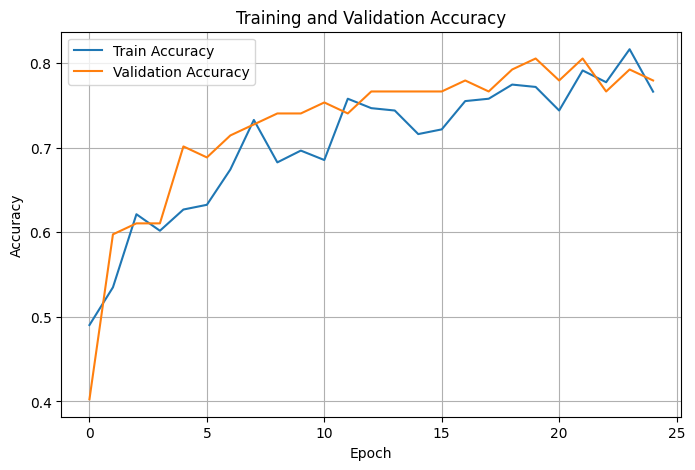

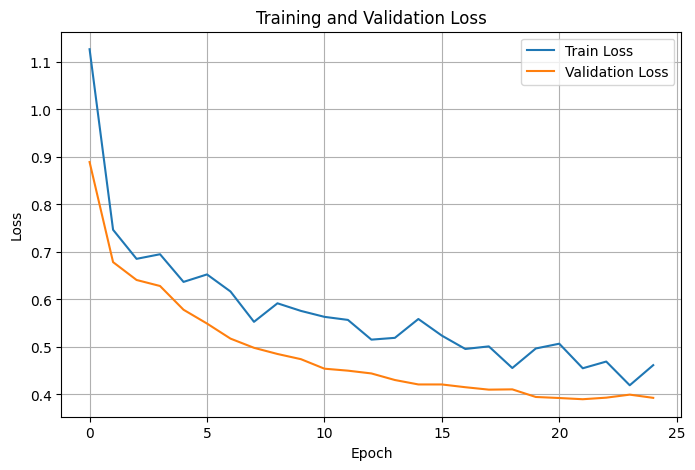

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
base_model.trainable = True

# Freeze lower layers, fine-tune only top part
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6908 - loss: 0.5286 - precision: 0.5694 - recall: 0.8500 - val_accuracy: 0.7792 - val_loss: 0.5427 - val_precision: 0.8824 - val_recall: 0.5000
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7911 - loss: 0.4368 - precision: 0.7305 - recall: 0.7357 - val_accuracy: 0.7662 - val_loss: 0.6145 - val_precision: 0.8750 - val_recall: 0.4667
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7994 - loss: 0.4185 - precision: 0.7179 - recall: 0.8000 - val_accuracy: 0.7662 - val_loss: 0.6144 - val_precision: 0.8750 - val_recall: 0.4667
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8357 - loss: 0.4069 - precision: 0.7485 - recall: 0.8714 - val_accuracy: 0.7792 - val_loss: 0.6619 - val_precision: 0.8824 - val_recall: 0.5000
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8468 - loss: 0.3507 - precision: 0.7815 - recall: 0.8429 - val_accuracy: 0.7792 - val_loss: 0.7530 - val

In [13]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)
print("Test F1-score:", f1_score)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 724ms/step - accuracy: 0.7051 - loss: 0.6447 - precision: 0.8333 - recall: 0.3226
Test Loss: 0.6447024941444397
Test Accuracy: 0.7051281929016113
Test Precision: 0.8333333134651184
Test Recall: 0.32258063554763794
Test F1-score: 0.4651162619580932


In [14]:
y_true = test_df["label"].values

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["genuine", "forged"]
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step  
              precision    recall  f1-score   support

     genuine       0.68      0.96      0.80        47
      forged       0.83      0.32      0.47        31

    accuracy                           0.71        78
   macro avg       0.76      0.64      0.63        78
weighted avg       0.74      0.71      0.66        78



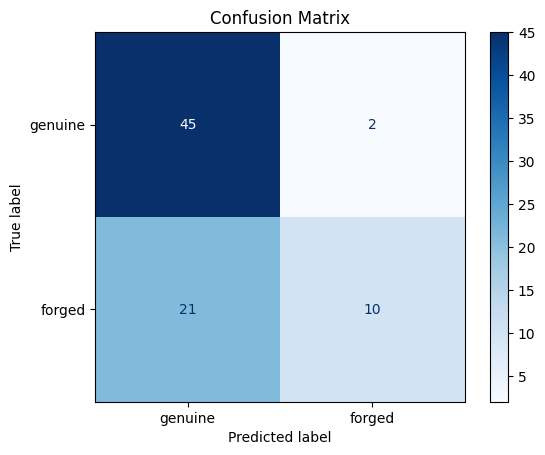

In [15]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["genuine", "forged"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [16]:
final_model_path = MODEL_OUTPUT_DIR / "stamp_resnet50_final.keras"

model.save(final_model_path)

print("Model saved to:")
print(final_model_path.resolve())

Model saved to:
D:\dev\forged-stamp-recognizer\outputs\models\stamp_resnet50_final.keras
